In [ ]:
from types import NoneType

import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator
import matplotlib.pyplot as plt
import numpy as np
import joblib
import json

In [24]:
with open("config.json", "r") as f:
    config: dict = json.load(f)

In [25]:
# Load section data
section_data = config["section"]

section_variables = []
for p in section_data["params"].keys():
    if section_data["params"][p]["variable"]:
        section_variables.append(p)
        
load_components = ["n", "mxx", "myy", "vx", "vy", "mzz"]

In [26]:
df = pd.read_csv("data.csv")
df = df.dropna()
assert df.isnull().sum().max() == 0, "DataFrame still contains NaN values after dropping."
print("Number of rows after dropping NaNs:", len(df))
df.head(100)

Number of rows after dropping NaNs: 9300


,d,b,t,r_out,n_r,section_param_id,n,mxx,myy,vx,vy,mzz,utilization
0,232.946650,143.795653,4.652269,13.539960,4,0,614734.881201,-2.224086e+07,2.943975e+07,83550.253057,39631.849963,-3.403051e+06,0.919592
1,232.946650,143.795653,4.652269,13.539960,4,0,-172989.452729,-6.593905e+06,-8.746633e+06,-233372.281083,146448.374178,1.175578e+06,0.955271
2,232.946650,143.795653,4.652269,13.539960,4,0,-659782.061565,1.158515e+07,4.333196e+06,264634.889996,78900.618981,-1.925261e+07,1.195924
3,232.946650,143.795653,4.652269,13.539960,4,0,-534157.663203,1.840638e+07,7.619930e+06,42629.300770,-183765.757303,-1.432708e+06,0.593238
4,232.946650,143.795653,4.652269,13.539960,4,0,348492.674194,-1.901896e+07,-1.439465e+07,127977.014228,268130.070355,4.256919e+06,1.015710
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,110.066232,153.380876,8.766342,13.507756,4,1,-975999.234182,-1.960091e+07,3.737155e+06,177858.608238,209114.727318,-7.298945e+06,1.191799
96,110.066232,153.380876,8.766342,13.507756,4,1,-180723.655356,-2.504713e+07,-1.367769e+07,-111368.587487,-268274.493224,-1.108868e+07,1.176117
97,110.066232,153.380876,8.766342,13.507756,4,1,-276255.092923,2.409931e+07,-1.506599e+07,184366.295128,188615.671859,-7.807002e+06,0.956898
98,110.066232,153.380876,8.766342,13.507756,4,1,464983.620598,1.639830e+07,-1.046417e+07,10924.918004,-42407.544139,-2.097973e+07,0.767823


In [27]:
X = df.drop(["utilization"], axis=1)
y = df[["utilization"]]
X.shape, y.shape

((9300, 12), (9300, 1))

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=df["section_param_id"]
)
X_train = X_train[section_variables + load_components]
X_test = X_test[section_variables + load_components]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (6231, 10)
Testing data shape: (3069, 10)


In [29]:
models = {}


def add_model(name:str, model:BaseEstimator, grid:dict | NoneType = None) -> None:
    steps = [
        ("scaling", StandardScaler()),
        ("regression", model)
    ]
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)
    models[name] = {"model": pipeline}
    if grid:
        models[name]["params_grid"] = grid
    

add_model("Linear Regression", LinearRegression())
add_model("Ridge Regression", Ridge(alpha=0.1), {"regression__alpha": np.arange(0.0001, 1, 10)})
add_model("Lasso Regression", Lasso(alpha=0.1), {"regression__alpha": np.arange(0.0001, 1, 10)})

models

{'Linear Regression': {'model': Pipeline(steps=[('scaling', StandardScaler()),
                  ('regression', LinearRegression())])},
 'Ridge Regression': {'model': Pipeline(steps=[('scaling', StandardScaler()),
                  ('regression', Ridge(alpha=0.1))]),
  'params_grid': {'regression__alpha': array([0.0001])}},
 'Lasso Regression': {'model': Pipeline(steps=[('scaling', StandardScaler()),
                  ('regression', Lasso(alpha=0.1))]),
  'params_grid': {'regression__alpha': array([0.0001])}}}

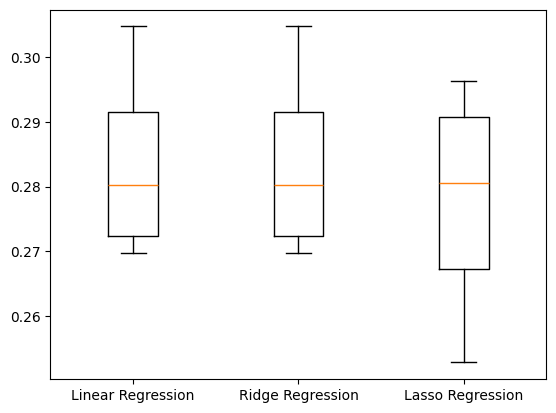

In [30]:
results = []
for model_name in models:
  model = models[model_name]["model"]
  
  # Define K-Fold cross-validation
  kf = KFold(n_splits=4, random_state=42, shuffle=True)
  
  # Perform cross-validation
  cv_scores = cross_val_score(model, X_train, y_train, cv=kf)
  
  # Append the results
  results.append(cv_scores)

# Create a box plot of the results
plt.boxplot(results, tick_labels=models.keys())
plt.show()

In [31]:
for model in models:
    
    if not "param_grid" in models[model]:
        continue
        
    kf = KFold(n_splits=4, random_state=42, shuffle=True)
    param_grid = models[model]["param_grid"]
    cv = RandomizedSearchCV(models[model]["model"], param_grid, cv=kf, n_iter=4)
    cv.fit(X_train, y_train)

    models[model]["model"] = cv.best_estimator_

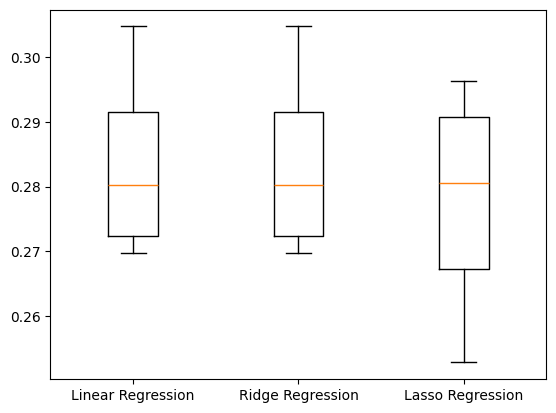

In [ ]:
# perform cross validation on all the models for the box plot
results = []
for model_name in models:
    model = models[model_name]["model"]
    
    # Define K-Fold cross-validation
    kf = KFold(n_splits=4, random_state=42, shuffle=True)
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf)
    
    # Append the results
    results.append(cv_scores)
    
    # Save the mean score
    models[model_name]["cv_mean"] = cv_scores.mean()

# Create a box plot of the results
plt.boxplot(results, tick_labels=models.keys())
plt.show()

In [33]:
best_model_name = max(models, key=lambda name: models[name].get("cv_mean", float('-inf')))
best_model = models[best_model_name]["model"]
print("Best model:", best_model_name)

with open("model.pkl", "wb") as f:
    joblib.dump(best_model, f, protocol=5)

Best model: Ridge Regression
